# Stochastic processes & Brownian motion

Prices evolve *randomly through time* — they are **stochastic processes**. The
continuous-time models in this section are the language of derivatives pricing,
mean-reversion, and risk, and they connect directly to the discrete models you
fit elsewhere in this collection.

* **Brownian motion** $W_t$ — the continuous limit of a random walk:
  independent Gaussian increments, $\operatorname{Var}(W_t)=t$. The building
  block of every diffusion.
* **Geometric Brownian motion (GBM)** — the textbook stock-price model
  $dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$, which keeps prices positive and makes
  returns lognormal. The model behind Black–Scholes.
* **Itô's lemma** — the calculus of random functions. Its famous consequence:
  the *geometric* growth rate of a stock is $\mu - \tfrac12\sigma^2$, **not**
  $\mu$ — volatility is a drag.
* **Ornstein–Uhlenbeck** — a *mean-reverting* diffusion, the basis of pairs
  trading and short-rate models (notebook 19).

**Roadmap**

1. Random walk → Brownian motion
2. Geometric Brownian motion — the lognormal price model
3. Itô's lemma & the volatility drag $\mu - \tfrac12\sigma^2$
4. Quadratic variation — where realized volatility comes from
5. Mean reversion — the Ornstein–Uhlenbeck process


In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from qufin.models.ou_process import OrnsteinUhlenbeck

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
rng = np.random.default_rng(0)


## 1. Random walk → Brownian motion

Sum $n$ i.i.d. $\pm1$ steps and rescale time by $1/n$ and space by
$1/\sqrt n$: as $n\to\infty$ the jagged random walk converges (Donsker's
theorem) to smooth **Brownian motion**. BM has three defining properties:
$W_0=0$; increments are independent and **Gaussian** with
$W_t-W_s\sim\mathcal N(0,\,t-s)$; and paths are continuous. The
$\operatorname{Var}(W_t)=t$ scaling is the $\sqrt T$ rule from notebook 01.


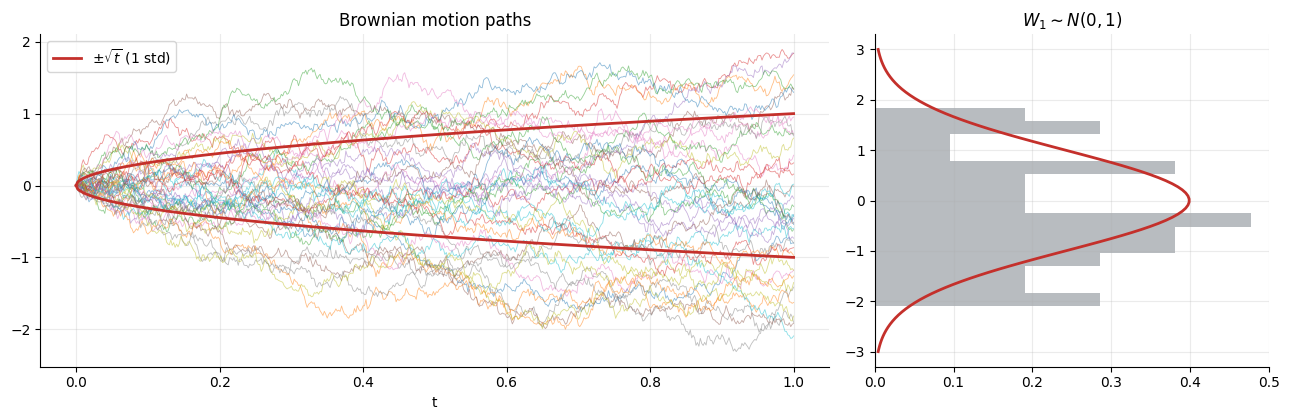

empirical Var(W_t):  t=0.25 -> 0.245,  t=0.5 -> 0.489,  t=1.0 -> 0.993  (= t)


In [2]:
def brownian_paths(n_paths, n_steps, T=1.0, seed=None):
    r = np.random.default_rng(seed)
    dt = T / n_steps
    dW = r.normal(0.0, np.sqrt(dt), size=(n_paths, n_steps))
    W = np.cumsum(dW, axis=1)
    return np.column_stack([np.zeros(n_paths), W])

t = np.linspace(0, 1, 501)
W = brownian_paths(40, 500, seed=1)
fig, (axp, axv) = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={'width_ratios': [2, 1]})
for k in range(40):
    axp.plot(t, W[k], lw=0.6, alpha=0.5)
axp.plot(t, np.sqrt(t), color='#c4302b', lw=2, label=r'$\pm\sqrt{t}$ (1 std)')
axp.plot(t, -np.sqrt(t), color='#c4302b', lw=2)
axp.set_title('Brownian motion paths'); axp.set_xlabel('t'); axp.legend()
# Terminal W_1 is N(0,1).
axv.hist(W[:, -1], bins=15, density=True, orientation='horizontal', color='#9aa0a6', alpha=0.7)
ys = np.linspace(-3, 3, 100); axv.plot(stats.norm.pdf(ys), ys, color='#c4302b', lw=2)
axv.set_title('$W_1 \\sim N(0,1)$')
plt.tight_layout(); plt.show()

big = brownian_paths(5000, 500, seed=2)
print(f'empirical Var(W_t):  t=0.25 -> {big[:,125].var():.3f},  '
      f't=0.5 -> {big[:,250].var():.3f},  t=1.0 -> {big[:,-1].var():.3f}  (= t)')


## 2. Geometric Brownian motion

A stock can't go negative and its *returns* (not levels) are what behave like
noise, so we model the **log-price** as a Brownian motion with drift. That gives
**geometric Brownian motion**, with the exact solution

$$ S_t = S_0\,\exp\!\Big[\big(\mu - \tfrac12\sigma^2\big)t + \sigma W_t\Big]. $$

So $S_t$ is **lognormal**, and log-returns over any horizon are exactly normal.
Real markets are *close* to this but with fatter tails and volatility clustering
(notebook 15) — GBM is the right first model, not the last word.


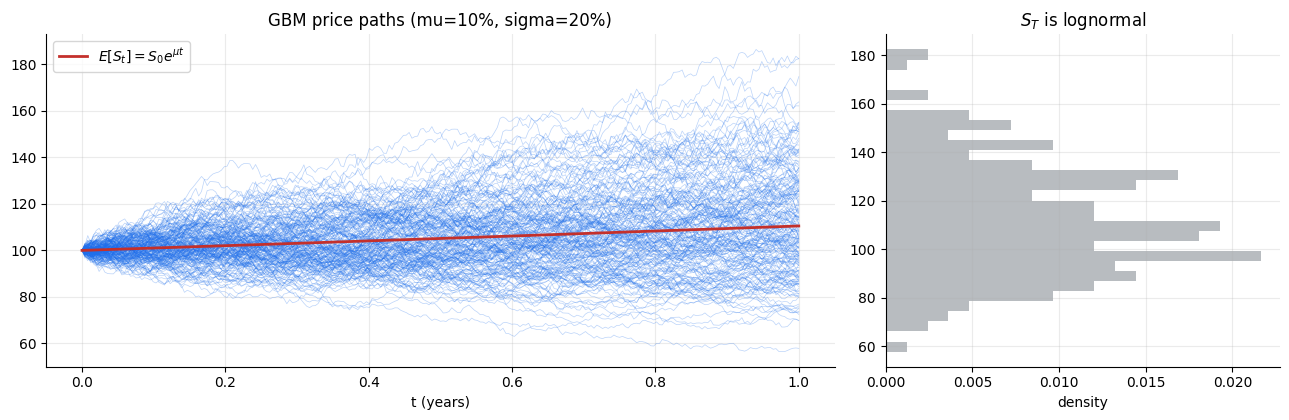

In [3]:
def gbm_paths(s0, mu, sigma, T, n_steps, n_paths, seed=None):
    r = np.random.default_rng(seed)
    dt = T / n_steps
    dW = r.normal(0.0, np.sqrt(dt), size=(n_paths, n_steps))
    incr = (mu - 0.5 * sigma**2) * dt + sigma * dW
    log_s = np.log(s0) + np.cumsum(incr, axis=1)
    return np.column_stack([np.full(n_paths, s0), np.exp(log_s)])

S = gbm_paths(100, mu=0.10, sigma=0.20, T=1.0, n_steps=252, n_paths=200, seed=3)
tt = np.linspace(0, 1, 253)
fig, (axp, axt) = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={'width_ratios': [2, 1]})
for k in range(200):
    axp.plot(tt, S[k], lw=0.5, alpha=0.3, color='#1f6feb')
axp.plot(tt, 100 * np.exp(0.10 * tt), color='#c4302b', lw=2, label=r'$E[S_t]=S_0e^{\mu t}$')
axp.set_title('GBM price paths (mu=10%, sigma=20%)'); axp.set_xlabel('t (years)'); axp.legend()
axt.hist(S[:, -1], bins=30, density=True, orientation='horizontal', color='#9aa0a6', alpha=0.7)
axt.set_title('$S_T$ is lognormal'); axt.set_xlabel('density')
plt.tight_layout(); plt.show()


## 3. Itô's lemma & the volatility drag

For ordinary calculus $d(\ln S)=dS/S$. But $S$ is random, and **Itô's lemma**
adds a second-order term because $(dW)^2 = dt$ is *not* negligible:

$$ d(\ln S_t) = \Big(\mu - \tfrac12\sigma^2\Big)dt + \sigma\,dW_t. $$

The $-\tfrac12\sigma^2$ is the **volatility drag**: the *median/geometric* growth
rate of a stock is below its *expected* (arithmetic) rate $\mu$. We verify it
with simulation — the mean log-return matches $\mu-\tfrac12\sigma^2$ while the
mean of $S_T$ matches $S_0e^{\mu T}$.


In [4]:
mu, sigma, T = 0.10, 0.40, 1.0          # a high vol to make the drag visible
big = gbm_paths(100, mu, sigma, T, n_steps=252, n_paths=200000, seed=4)
log_growth = np.log(big[:, -1] / big[:, 0]).mean() / T
arith_growth = (big[:, -1].mean() / big[:, 0] - 1) / T  # ~ e^{mu T}-1 over T
print(f'expected (arithmetic) rate mu          = {mu:.4f}')
print(f'mean of E[S_T]/S_0 implies             ~ {np.log(big[:,-1].mean()/100)/T:.4f}  (= mu)')
print(f'mean LOG-return per year (geometric)   = {log_growth:.4f}')
print(f'theory mu - 0.5*sigma^2                = {mu - 0.5*sigma**2:.4f}  <- the drag')
print(f'\nWith sigma={sigma:.0%}, volatility shaves '
      f'{0.5*sigma**2:.1%}/yr off the compound growth rate.')


expected (arithmetic) rate mu          = 0.1000
mean of E[S_T]/S_0 implies             ~ 0.0993  (= mu)
mean LOG-return per year (geometric)   = 0.0193
theory mu - 0.5*sigma^2                = 0.0200  <- the drag

With sigma=40%, volatility shaves 8.0%/yr off the compound growth rate.


## 4. Quadratic variation → realized volatility

A defining feature of Brownian motion: summing **squared** increments over
$[0,t]$ converges to $t$ no matter how finely you sample — the *quadratic
variation* $[W]_t = t$. For a diffusion with volatility $\sigma$, the quadratic
variation of the log-price accumulates $\sigma^2 t$. That is precisely why
**summing squared intraday returns estimates the variance** — the foundation of
**realized volatility** (notebook 16).


In [5]:
for n in (50, 200, 1000, 5000):
    w = brownian_paths(1, n, T=1.0, seed=7)[0]
    qv = np.sum(np.diff(w) ** 2)
    print(f'n={n:>5} steps:  sum of squared increments = {qv:.4f}   (-> [W]_1 = 1)')

# Realized variance of a GBM log-price recovers sigma^2.
sig = 0.25
one = gbm_paths(100, 0.05, sig, T=1.0, n_steps=5000, n_paths=1, seed=8)[0]
realized_var = np.sum(np.diff(np.log(one)) ** 2)
print(f'\nGBM with sigma={sig}: realized variance of log-price = {realized_var:.4f}  '
      f'(sigma^2 = {sig**2:.4f})')


n=   50 steps:  sum of squared increments = 0.8689   (-> [W]_1 = 1)
n=  200 steps:  sum of squared increments = 0.7783   (-> [W]_1 = 1)
n= 1000 steps:  sum of squared increments = 0.8913   (-> [W]_1 = 1)
n= 5000 steps:  sum of squared increments = 0.9879   (-> [W]_1 = 1)

GBM with sigma=0.25: realized variance of log-price = 0.0635  (sigma^2 = 0.0625)


## 5. Mean reversion — the Ornstein–Uhlenbeck process

Brownian motion wanders forever; many financial series instead **revert** to a
level — spreads, volatility, short rates. The **Ornstein–Uhlenbeck** process adds
a restoring pull,

$$ dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t, $$

so deviations decay at speed $\theta$ (half-life $\ln 2/\theta$). Contrast a BM
(diffuses, variance grows without bound) with an OU process (settles into a
stationary band). This is the model behind notebooks 19 (mean reversion) and 20
(pairs).


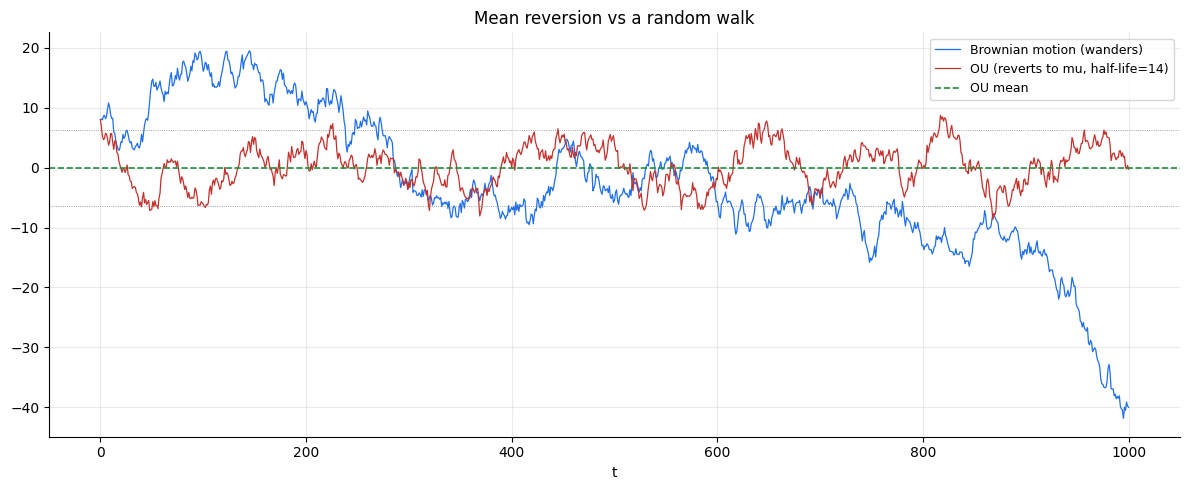

OU stationary std = sigma/sqrt(2*theta) = 3.16; BM std keeps growing without bound.


In [6]:
ou = OrnsteinUhlenbeck(theta=0.05, mu=0.0, sigma=1.0, dt=1.0)   # half-life ~14
ou_path = ou.simulate(n_steps=1000, x0=8.0, seed=5)            # start far from mu
bm_path = np.concatenate([[8.0], 8.0 + np.cumsum(rng.normal(0, 1.0, 1000))])  # BM from 8.0

fig, ax = plt.subplots()
ax.plot(bm_path, color='#1f6feb', lw=0.9, label='Brownian motion (wanders)')
ax.plot(ou_path, color='#c4302b', lw=0.9, label=f'OU (reverts to mu, half-life={ou.half_life:.0f})')
ax.axhline(0.0, color='#1f8e3a', lw=1.2, ls='--', label='OU mean')
ax.axhline(ou.stationary_std * 2, color='#888', lw=0.6, ls=':')
ax.axhline(-ou.stationary_std * 2, color='#888', lw=0.6, ls=':')
ax.set_title('Mean reversion vs a random walk'); ax.set_xlabel('t'); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print(f'OU stationary std = sigma/sqrt(2*theta) = {ou.stationary_std:.2f}; '
      'BM std keeps growing without bound.')


## What next?

* **Monte Carlo & numerical methods (notebook 09)** uses GBM paths to *price*
  options and back out implied volatility.
* **Options (notebooks 25–27)** are built on the GBM/Black–Scholes world; the
  Greeks are Itô sensitivities.
* **Mean reversion (19)** and **cointegration & pairs (20)** estimate and trade
  the OU process introduced here.
* **GARCH (15)** and **realized volatility (16)** are what you reach for once you
  accept that real $\sigma$ is *not* constant, unlike in GBM.
